<a href="https://colab.research.google.com/github/JustMeshal/Iris-Classification/blob/main/iris_rf_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
import joblib

In [ ]:
df = pd.read_csv('Iris.csv')
print('Shape:', df.shape)
df.head()

Shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [ ]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [ ]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [ ]:
df['Species'].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

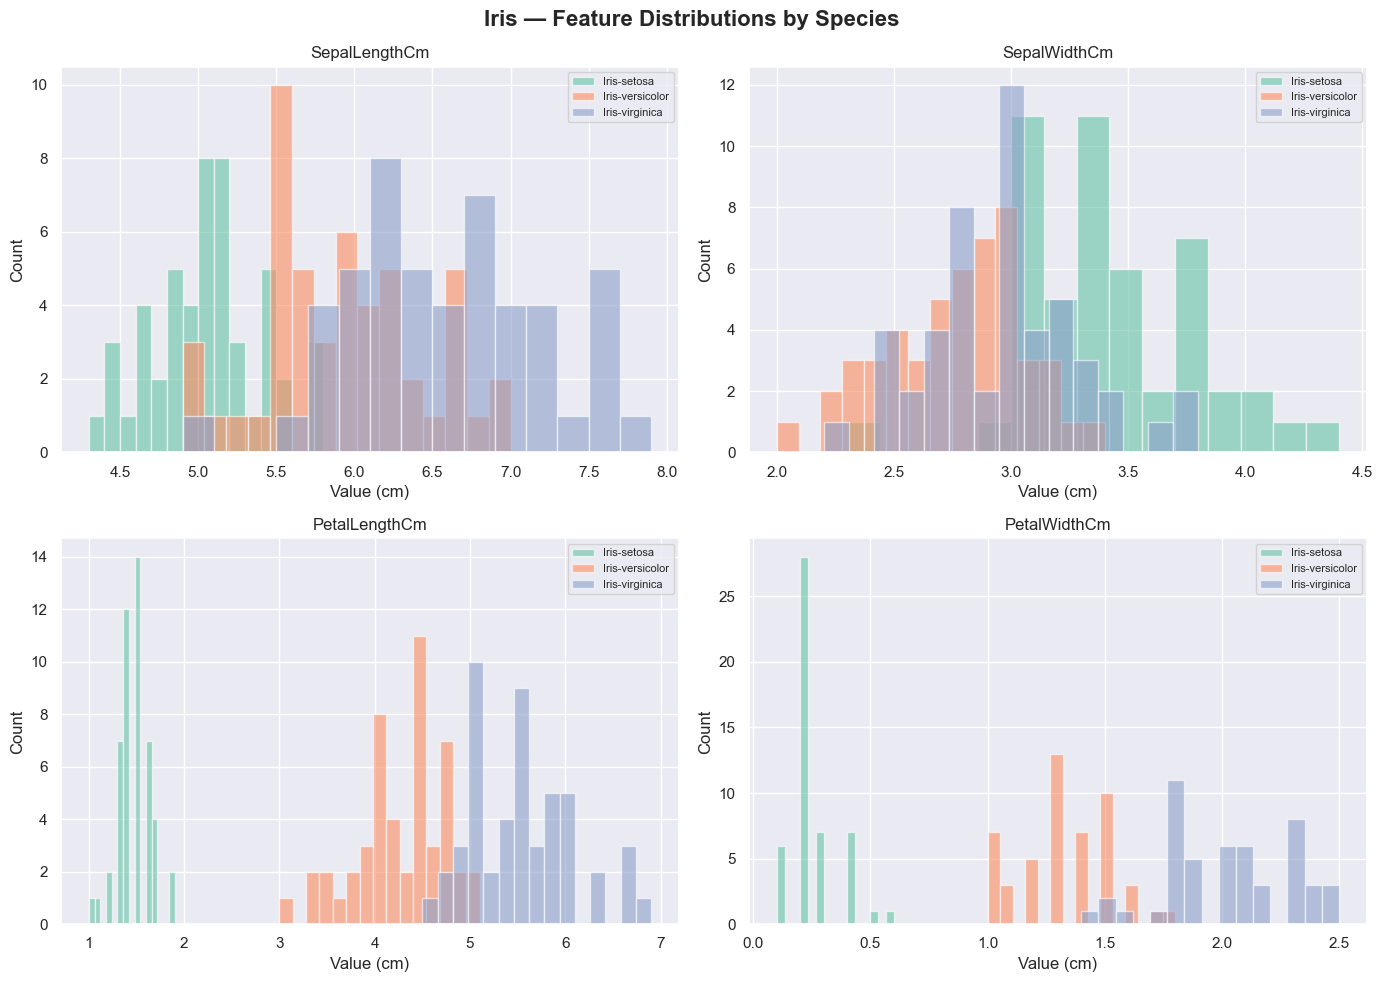

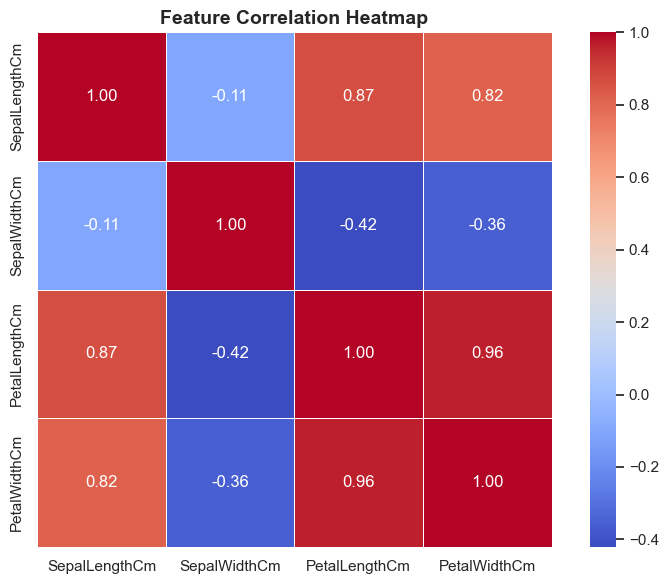

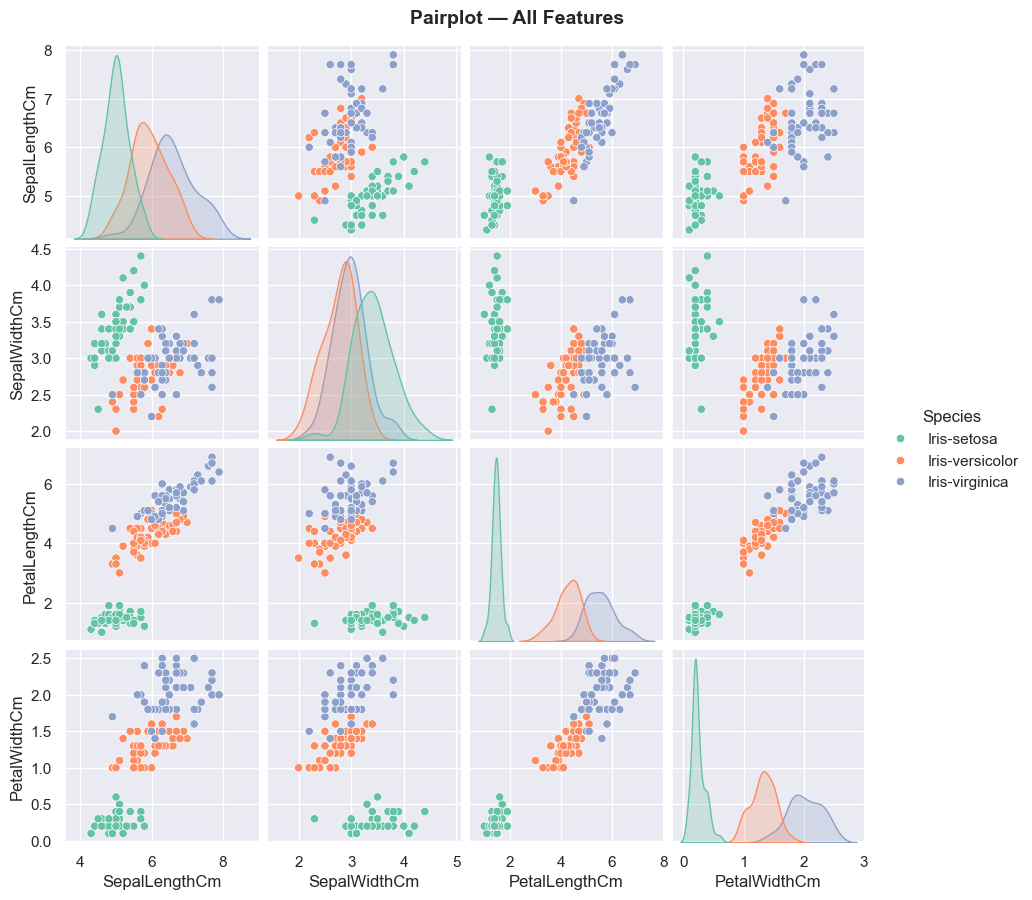

In [ ]:
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
sns.set_theme(style='darkgrid', palette='Set2')
# Histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Iris — Feature Distributions by Species', fontsize=16, fontweight='bold')
for ax, feature in zip(axes.flatten(), features):
    for species in df['Species'].unique():
        ax.hist(df[df['Species'] == species][feature], alpha=0.6, label=species, bins=15)
    ax.set_title(feature)
    ax.set_xlabel('Value (cm)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[features].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# Pairplot
sns.pairplot(df[features + ['Species']], hue='Species', diag_kind='kde', height=2.2)
plt.suptitle('Pairplot — All Features', y=1.02, fontsize=14, fontweight='bold')
plt.show()

Overall, the visualizations show that petal features are more effective than sepal features for identifying Iris species. The strong correlation between Petal Length and Petal Width also indicates that these two features contain similar information and can be very useful for classification models.

In [ ]:
df.drop(columns=['Id'], inplace=True)
X = df.drop(columns=['Species'])
y = df['Species']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f'Train : {X_train.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')

Train : 120 samples
Test  : 30 samples


In [ ]:
model = RandomForestClassifier(random_state=42)

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
scores = cross_val_score(
    model,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

print('5-Fold CV Scores :', scores.round(3)*100)
print('Mean Accuracy    :', scores.mean().round(3)*100)
print('Std Dev          :', scores.std().round(3)*100)

5-Fold CV Scores : [96.7 96.7 93.3 96.7 90. ]
Mean Accuracy    : 94.69999999999999
Std Dev          : 2.7


In [ ]:
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2],
    'max_features'     : ['sqrt', 'log2']
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)
print('Best Params:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV Accuracy: {grid_search.best_score_*100:.4f}')
best_rf = grid_search.best_estimator_

Best Params:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 5
  n_estimators: 50

Best CV Accuracy: 96.6667


In [ ]:
y_pred = best_rf.predict(X_test)

print(classification_report(y_test, y_pred))

print('Accuracy :', round(accuracy_score(y_test, y_pred)*100, 4))
print('F1 Score :', round(f1_score(y_test, y_pred, average='weighted')*100, 4))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

Accuracy : 96.6667
F1 Score : 96.6583


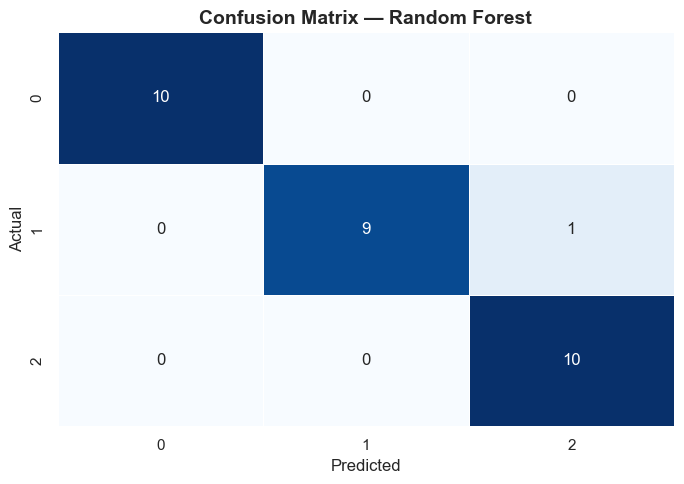

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5, cbar=False)
plt.title('Confusion Matrix — Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

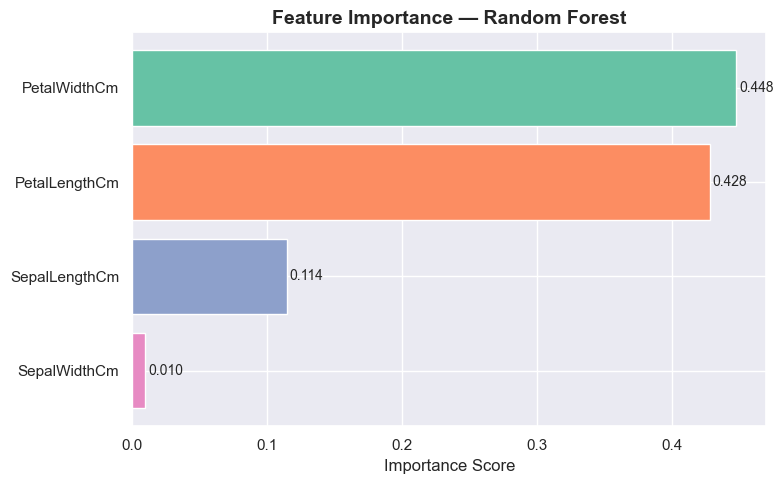

In [ ]:
feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)
plt.figure(figsize=(8, 5))
bars = plt.barh(feat_df['Feature'], feat_df['Importance'],
                color=sns.color_palette('Set2', len(feat_df)))
for bar, val in zip(bars, feat_df['Importance']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10)
plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


The most important features for predicting Iris species are PetalWidthCm and PetalLengthCm, with importance scores of 0.448 and 0.428, respectively. Together, they account for approximately 87.6% of the total feature importance. SepalLengthCm has a smaller contribution (0.114), while SepalWidthCm is the least important feature (0.010).

In [ ]:
joblib.dump(best_rf, 'iris_rf_model.pkl')
print('Model saved!')

Model saved!


In [ ]:
new_sample = pd.DataFrame(
    [[6.5, 3.0, 5.2, 2.0]],
    columns=X.columns
)

prediction = best_rf.predict(new_sample)
probability = best_rf.predict_proba(new_sample)

print('Predicted:', prediction[0])
print('Confidence:', f'{probability.max()*100:.2f}%')

for cls, prob in zip(best_rf.classes_, probability[0]):
    print(f'  {cls:<22} -> {prob*100:.2f}%')

Predicted: Iris-virginica
Confidence: 100.00%
  Iris-setosa            -> 0.00%
  Iris-versicolor        -> 0.00%
  Iris-virginica         -> 100.00%
